In [152]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np


# Settings 
pd.set_option("display.max_rows", None, "display.max_columns", None)


PATH = "Data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [153]:
print("Shape:", df.shape)
print(df.dtypes)


Shape: (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [154]:
df = df.drop(columns=["customerID"])

In [155]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

df = df.dropna()

In [156]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [157]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = df.columns.drop(numeric_cols + ["Churn"])

print("Numerik:", numeric_cols)
print("Kategorikal:", list(categorical_cols))


Numerik: ['tenure', 'MonthlyCharges', 'TotalCharges']
Kategorikal: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [158]:
X = df[numeric_cols]
y = df["Churn"]

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Cross Val Mean:", scores.mean())
print("Cross Val Std:", scores.std())


Cross Val Mean: 0.7851250756985243
Cross Val Std: 0.007033816714408396


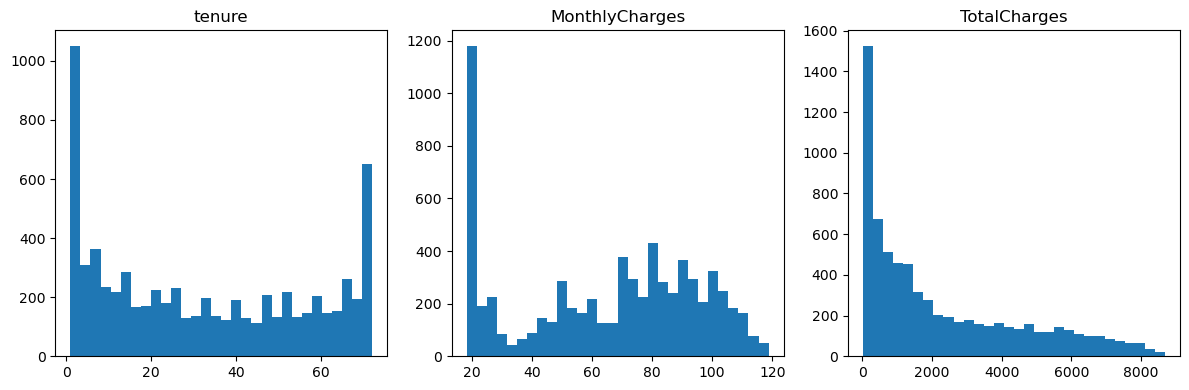

In [159]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[numeric_cols]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [161]:
model = LogisticRegression(max_iter=1000)
scores_scaled = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")

print("Scaled CV Mean:", scores_scaled.mean())
print("Scaled CV Std:", scores_scaled.std())

Scaled CV Mean: 0.7864888888888889
Scaled CV Std: 0.00813515462303826


In [162]:
df_encoded = pd.DataFrame()

# Ordinal
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df_encoded["Contract"] = df["Contract"].map(contract_map)

# One-hot
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    
)

# Binary mapping
binary_cols = ["gender", "Partner", "Dependents", "PhoneService"]

for col in binary_cols:
    df_encoded[col] = df[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,Partner,Dependents,PhoneService
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0,1,0,0
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,1,0,0,1
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,1,0,0,1
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,1,0,0,0
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0,0,0,1


In [163]:
X_num = df_encoded[numeric_cols]
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_num_scaled = pd.DataFrame(X_num_scaled, columns=numeric_cols, index=df_encoded.index)

X_final = pd.concat([X_num_scaled, df_encoded.drop(columns=numeric_cols + ["Churn"])], axis=1)
y = df_encoded["Churn"]
X_final.head(10)



,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,Partner,Dependents,PhoneService
0,-1.280248,-1.161694,-0.994194,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0,1,0,0
1,0.064303,-0.260878,-0.173740,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,1,0,0,1
2,-1.239504,-0.363923,-0.959649,0,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,1,0,0,1
3,0.512486,-0.747850,-0.195248,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,1,0,0,0
4,-1.239504,0.196178,-0.940457,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0,0,0,1
5,-0.995040,1.158489,-0.645369,0,False,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,0,0,0,1
6,-0.424625,0.807802,-0.147313,0,True,False,True,True,False,True,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,True,False,False,1,0,1,1
7,-0.913552,-1.165018,-0.874169,0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,0,0,0
8,-0.180161,1.329677,0.336516,0,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False,0,1,0,1
9,1.205134,-0.287470,0.531476,0,True,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,1,0,1,1


In [164]:
model = LogisticRegression(max_iter=1000)

scores_final = cross_val_score(model, X_final, y, cv=5, scoring="accuracy")

print("Final CV Mean:", scores_final.mean())
print("Final CV Std:", scores_final.std())

Final CV Mean: 0.8037532314044491
Final CV Std: 0.007153207340520977


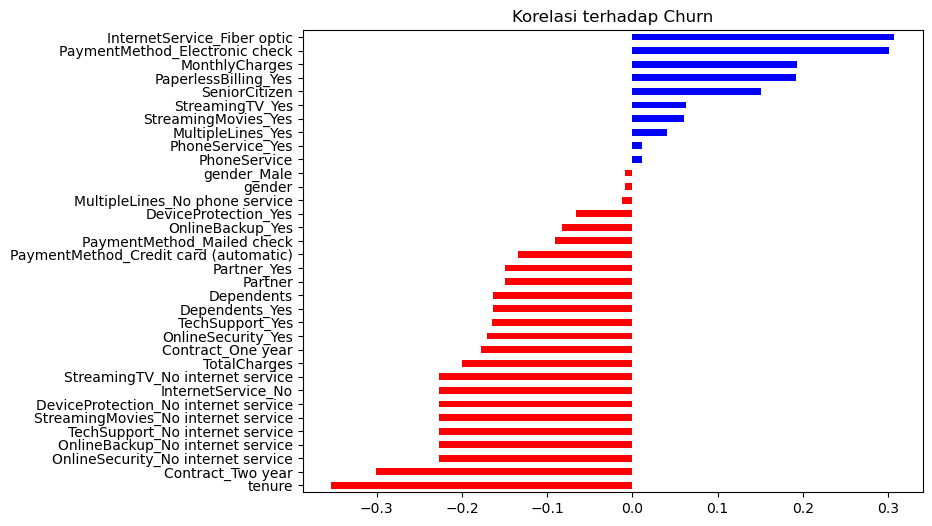

In [165]:
import numpy as np

corr = X_final.corrwith(y)

corr_sorted = corr.sort_values()

colors = ["red" if c < 0 else "blue" for c in corr_sorted]

plt.figure(figsize=(8,6))
corr_sorted.plot(kind="barh", color=colors)
plt.title("Korelasi terhadap Churn")
plt.show()

In [166]:
selected_features = corr[abs(corr) > 0.10].index.tolist()
print("Selected Features:", selected_features)

Selected Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner_Yes', 'Dependents_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'Partner', 'Dependents']


In [167]:
X_selected = X_final[selected_features]

scores_selected = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Selected CV Mean:", scores_selected.mean())
print("Selected CV Std:", scores_selected.std())

Selected CV Mean: 0.8028998474403031
Selected CV Std: 0.0073587728336999845
